In [ ]:
!pip install catboost optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 35.6 MB/s eta 0:00:00


# Ансамблевые методы

## 1. Загрузка и подготовка данных

В этом разделе мы:
- Загружаем датасет из репозитория
- Удаляем ненужные колонки
- Оставляем только бинарную классификацию (классы 0 и 1)
- Разделяем данные на обучающую и тестовую выборки
- Масштабируем признаки

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Импорт из sklearn
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss, confusion_matrix, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Ансамблевые модели
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Оптимизация гиперпараметров
import optuna

In [ ]:
# Загрузка датасета
url = "https://raw.githubusercontent.com/MariaKhudiakova/cirrhosis-prediction/main/data/data_with_features.csv"
train_df = pd.read_csv(url, index_col=0)

# Удаление лишних колонок
del_columns = ['Unnamed: 0', 'N_Days']
for del_column in del_columns:
    if del_column in train_df.columns:
        train_df = train_df.drop(del_column, axis=1)

# Оставляем только два класса (бинарная классификация)
binary_mask = train_df['Status_encoded'].isin([0, 1])
train_df_binary = train_df[binary_mask].copy()

print(f"Размер датасета: {train_df_binary.shape}")
print(f"Распределение классов:\n{train_df_binary['Status_encoded'].value_counts()}")

Размер датасета: (7630, 25)
Распределение классов:
Status_encoded
1    4965
0    2665
Name: count, dtype: int64


In [ ]:
# Подготовка данных
X = train_df_binary.drop("Status_encoded", axis=1)
y = train_df_binary["Status_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Применение SMOTE для балансировки классов
# print(f"\nРаспределение классов до SMOTE:\n{y_train.value_counts()}")
# smote = SMOTE(random_state=42)
# X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
# print(f"Распределение классов после SMOTE:\n{y_train_smote.value_counts()}")

# Масштабирование данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 2. Сравнение базовых моделей

В этом разделе мы сравниваем производительность различных ансамблевых моделей
с параметрами по умолчанию:

- Random Forest: ансамбль деревьев решений
- XGBoost: градиентный бустинг с деревьями
- LightGBM: оптимизированный градиентный бустинг
- CatBoost: бустинг от Яндекса с обработкой категориальных признаков
- Decision Tree: одиночное дерево решений (для сравнения)

Метрики оценки:
- CV F1: среднее F1-score на кросс-валидации (основная метрика)
- Test Accuracy: точность на тестовой выборке
- Test Precision: точность предсказания положительного класса
- Test Recall: полнота предсказания положительного класса
- Test F1: F1-мера на тестовой выборке
- Test ROC-AUC: площадь под ROC-кривой

In [ ]:
init_models = {
    'Random Forest Classifier': RandomForestClassifier(random_state=42),
    'XGBoost Classifier': XGBClassifier(random_state=42),
    'LightGBM Classifier': LGBMClassifier(random_state=42, verbose=-1),
    'CatBoost': CatBoostClassifier(random_state=42, verbose=False),
    'Decision Tree Classifier': DecisionTreeClassifier(random_state=42)
}

In [ ]:
# Сравнение базовых моделей
results = []
for name, model in init_models.items():
    print(f"\nОбучение модели: {name}")

    # Кросс-валидация
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='f1')

    # Обучение на полном тренировочном наборе
    model.fit(X_train_scaled, y_train)

    # Предсказания
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Метрики
    metrics = {
        'Модель': name,
        'CV_F1': cv_scores.mean(),
        'Test_Accuracy': accuracy_score(y_test, y_pred),
        'Test_Precision': precision_score(y_test, y_pred),
        'Test_Recall': recall_score(y_test, y_pred),
        'Test_F1': f1_score(y_test, y_pred),
        'Test_ROC_AUC': roc_auc_score(y_test, y_proba)
    }

    results.append(metrics)

    print(f"CV F1: {metrics['CV_F1']:.4f}")
    print(f"Test F1: {metrics['Test_F1']:.4f}")


Обучение модели: Random Forest Classifier
CV F1: 0.8778
Test F1: 0.8775

Обучение модели: XGBoost Classifier
CV F1: 0.8768
Test F1: 0.8771

Обучение модели: LightGBM Classifier
CV F1: 0.8844
Test F1: 0.8877

Обучение модели: CatBoost
CV F1: 0.8856
Test F1: 0.8837

Обучение модели: Decision Tree Classifier
CV F1: 0.8199
Test F1: 0.8206


In [ ]:
# Сравнение моделей
results_df = pd.DataFrame(results)
print("\nСравнение моделей (отсортировано по F1-score):")
results_df_sorted = results_df.sort_values('Test_F1', ascending=False)
print(results_df_sorted)


Сравнение моделей (отсортировано по F1-score):
                     Модель     CV_F1  Test_Accuracy  Test_Precision  \
2       LightGBM Classifier  0.884381       0.850590        0.868852   
3                  CatBoost  0.885577       0.845347        0.864995   
0  Random Forest Classifier  0.877816       0.836828        0.857692   
1        XGBoost Classifier  0.876809       0.837484        0.863415   
4  Decision Tree Classifier  0.819867       0.764744        0.814484   

   Test_Recall   Test_F1  Test_ROC_AUC  
2     0.907351  0.887685      0.908162  
3     0.903323  0.883744      0.911399  
0     0.898288  0.877521      0.899993  
1     0.891239  0.877106      0.895316  
4     0.826788  0.820590      0.737972  


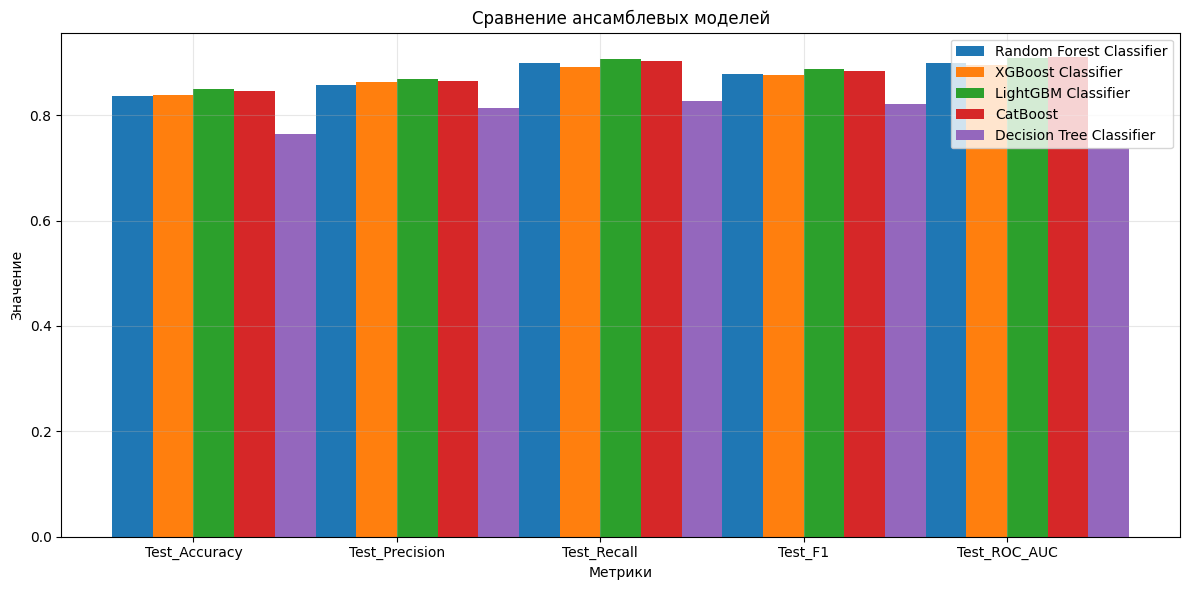

In [ ]:
# Визуализация результатов
plt.figure(figsize=(12, 6))
metrics_to_plot = ['Test_Accuracy', 'Test_Precision', 'Test_Recall', 'Test_F1', 'Test_ROC_AUC']
x = np.arange(len(metrics_to_plot))
width = 0.2

for i, model_name in enumerate(results_df['Модель']):
    model_metrics = results_df[results_df['Модель'] == model_name].iloc[0]
    values = [model_metrics[metric] for metric in metrics_to_plot]
    plt.bar(x + i*width, values, width, label=model_name)

plt.xlabel('Метрики')
plt.ylabel('Значение')
plt.title('Сравнение ансамблевых моделей')
plt.xticks(x + width*1.5, metrics_to_plot)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. Оптимизация гиперпараметров

Для оптимизации гиперпараметров мы используем библиотеку Optuna,
которая эффективно ищет оптимальные параметры с помощью байесовской оптимизации.

Оптимизируем три лучшие модели:
- XGBoost: оптимизация количества деревьев, глубины, скорости обучения и др.
- LightGBM: аналогичные параметры с учетом специфики алгоритма
- CatBoost: оптимизация итераций, глубины, регуляризации

Критерии оптимизации:
- CV ROC-AUC: площадь под ROC-кривой на кросс-валидации

Результат: лучшие гиперпараметры для каждой модели.

In [ ]:
# Оптимизация гиперпараметров для XGBoost
def objective_xgb(trial):
    params = {
        "n_estimators": trial.suggest_int('n_estimators', 500, 750),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.05, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.05, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        'random_state': 42
    }

    model = XGBClassifier(**params)

    # Кросс-валидация
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    return cv_scores.mean()

print("\nОптимизация гиперпараметров XGBoost с Optuna...")
study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=20, timeout=300)

print(f"XGBoost - Лучшие параметры: {study_xgb.best_params}")
print(f"XGBoost - Лучший CV ROC-AUC: {study_xgb.best_value:.4f}")

[I 2025-12-21 17:31:29,950] A new study created in memory with name: no-name-8c5d1ef9-fd3e-4a9f-af86-9c43ca6ba9f6



Оптимизация гиперпараметров XGBoost с Optuna...


[I 2025-12-21 17:31:31,175] Trial 0 finished with value: 0.8915443024597544 and parameters: {'n_estimators': 554, 'learning_rate': 0.011995725900397321, 'max_depth': 1, 'subsample': 0.09575629104216227, 'colsample_bytree': 0.6938847774964937, 'min_child_weight': 12}. Best is trial 0 with value: 0.8915443024597544.
[I 2025-12-21 17:31:33,485] Trial 1 finished with value: 0.897956147099827 and parameters: {'n_estimators': 521, 'learning_rate': 0.049024184483601865, 'max_depth': 1, 'subsample': 0.14606748314232593, 'colsample_bytree': 0.21722692496310808, 'min_child_weight': 14}. Best is trial 1 with value: 0.897956147099827.
[I 2025-12-21 17:32:05,944] Trial 2 finished with value: 0.9000095362683558 and parameters: {'n_estimators': 688, 'learning_rate': 0.0017897530896796936, 'max_depth': 9, 'subsample': 0.6955001153076114, 'colsample_bytree': 0.8495308618705047, 'min_child_weight': 1}. Best is trial 2 with value: 0.9000095362683558.
[I 2025-12-21 17:32:10,209] Trial 3 finished with valu

XGBoost - Лучшие параметры: {'n_estimators': 720, 'learning_rate': 0.017515748252264113, 'max_depth': 3, 'subsample': 0.6057966592665368, 'colsample_bytree': 0.5624336728396903, 'min_child_weight': 5}
XGBoost - Лучший CV ROC-AUC: 0.9083


In [ ]:
# Оптимизация гиперпараметров для LightGBM
def objective_lgb(trial):
    params = {
        "n_estimators": trial.suggest_int('n_estimators', 500, 750),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.1, log=True),
        "max_depth": trial.suggest_int("max_depth", 1, 10),
        "subsample": trial.suggest_float("subsample", 0.05, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.05, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 20),
        'random_state': 42,
        'verbose': -1
    }

    model = LGBMClassifier(**params)

    # Кросс-валидация
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    return cv_scores.mean()

print("\nОптимизация гиперпараметров LightGBM с Optuna...")
study_lgb = optuna.create_study(direction='maximize')
study_lgb.optimize(objective_lgb, n_trials=20, timeout=300)

print(f"LightGBM - Лучшие параметры: {study_lgb.best_params}")
print(f"LightGBM - Лучший CV ROC-AUC: {study_lgb.best_value:.4f}")

[I 2025-12-21 17:33:14,742] A new study created in memory with name: no-name-2965eb32-0407-46fc-880a-e76dfd7d0fe8



Оптимизация гиперпараметров LightGBM с Optuna...


[I 2025-12-21 17:33:16,734] Trial 0 finished with value: 0.8976198992189193 and parameters: {'n_estimators': 743, 'learning_rate': 0.008952297739164249, 'max_depth': 2, 'subsample': 0.3197561911942813, 'colsample_bytree': 0.7696489079954696, 'min_child_weight': 15}. Best is trial 0 with value: 0.8976198992189193.
[I 2025-12-21 17:33:20,350] Trial 1 finished with value: 0.9049811670018798 and parameters: {'n_estimators': 592, 'learning_rate': 0.040800571666644664, 'max_depth': 7, 'subsample': 0.8657820396538656, 'colsample_bytree': 0.5755434237060725, 'min_child_weight': 8}. Best is trial 1 with value: 0.9049811670018798.
[I 2025-12-21 17:33:21,545] Trial 2 finished with value: 0.8899174670320621 and parameters: {'n_estimators': 614, 'learning_rate': 0.01072188293602547, 'max_depth': 1, 'subsample': 0.27351068790076816, 'colsample_bytree': 0.4937686094637716, 'min_child_weight': 2}. Best is trial 1 with value: 0.9049811670018798.
[I 2025-12-21 17:33:23,887] Trial 3 finished with value: 

LightGBM - Лучшие параметры: {'n_estimators': 609, 'learning_rate': 0.03249044873346766, 'max_depth': 3, 'subsample': 0.448546431013569, 'colsample_bytree': 0.48582811420236166, 'min_child_weight': 8}
LightGBM - Лучший CV ROC-AUC: 0.9086


In [ ]:
# Оптимизация гиперпараметров для CatBoost
def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 100, 500),
        'depth': trial.suggest_int('depth', 3, 10),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'random_state': 42,
        'verbose': False
    }

    model = CatBoostClassifier(**params)

    # Кросс-валидация
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='roc_auc')
    return cv_scores.mean()

print("\nОптимизация гиперпараметров CatBoost с Optuna...")
study_cat = optuna.create_study(direction='maximize')
study_cat.optimize(objective_cat, n_trials=20, timeout=300)

print(f"CatBoost - Лучшие параметры: {study_cat.best_params}")
print(f"CatBoost - Лучший CV ROC-AUC: {study_cat.best_value:.4f}")

[I 2025-12-21 17:34:03,672] A new study created in memory with name: no-name-b2555a62-8d46-48cc-9c67-84e5760087c8



Оптимизация гиперпараметров CatBoost с Optuna...


[I 2025-12-21 17:34:30,649] Trial 0 finished with value: 0.9071337356608682 and parameters: {'iterations': 419, 'depth': 8, 'learning_rate': 0.032490209647272075, 'l2_leaf_reg': 3.996438244728513}. Best is trial 0 with value: 0.9071337356608682.
[I 2025-12-21 17:34:36,202] Trial 1 finished with value: 0.9004573429991376 and parameters: {'iterations': 367, 'depth': 4, 'learning_rate': 0.19997730235114902, 'l2_leaf_reg': 2.031238613930714}. Best is trial 0 with value: 0.9071337356608682.
[I 2025-12-21 17:35:13,721] Trial 2 finished with value: 0.9053647476328314 and parameters: {'iterations': 308, 'depth': 9, 'learning_rate': 0.02153101993057695, 'l2_leaf_reg': 5.273985555949269}. Best is trial 0 with value: 0.9071337356608682.
[I 2025-12-21 17:35:22,201] Trial 3 finished with value: 0.9014692860949418 and parameters: {'iterations': 321, 'depth': 6, 'learning_rate': 0.13825105249784758, 'l2_leaf_reg': 1.0425954164670201}. Best is trial 0 with value: 0.9071337356608682.
[I 2025-12-21 17:3

CatBoost - Лучшие параметры: {'iterations': 419, 'depth': 8, 'learning_rate': 0.032490209647272075, 'l2_leaf_reg': 3.996438244728513}
CatBoost - Лучший CV ROC-AUC: 0.9071


In [ ]:
# Сравнение оптимизированных моделей
print("\nСРАВНЕНИЕ ОПТИМИЗИРОВАННЫХ МОДЕЛЕЙ:")
print(f"XGBoost CV ROC-AUC: {study_xgb.best_value:.4f}")
print(f"LightGBM CV ROC-AUC: {study_lgb.best_value:.4f}")
print(f"CatBoost CV ROC-AUC: {study_cat.best_value:.4f}")


СРАВНЕНИЕ ОПТИМИЗИРОВАННЫХ МОДЕЛЕЙ:
XGBoost CV ROC-AUC: 0.9083
LightGBM CV ROC-AUC: 0.9086
CatBoost CV ROC-AUC: 0.9071


In [ ]:
# Выбор лучшей оптимизированной модели
model_scores = {
    'XGBoost': study_xgb.best_value,
    'LightGBM': study_lgb.best_value,
    'CatBoost': study_cat.best_value
}

best_model_name = max(model_scores, key=model_scores.get)
best_score = model_scores[best_model_name]

if best_model_name == 'XGBoost':
    best_params = study_xgb.best_params
    best_model_class = XGBClassifier
elif best_model_name == 'LightGBM':
    best_params = study_lgb.best_params
    best_model_class = LGBMClassifier
else:  # CatBoost
    best_params = study_cat.best_params
    best_model_class = CatBoostClassifier

print(f"\nЛучшая оптимизированная модель: {best_model_name}")


Лучшая оптимизированная модель: LightGBM


## 4. Финальная оценка и визуализация результатов

После оптимизации гиперпараметров мы:
- Обучаем финальные модели с оптимальными параметрами
- Сравниваем производительность всех трех оптимизированных моделей
- Строим Confusion Matrix для лучшей модели
- Строим ROC-кривые для визуального сравнения моделей
- Делаем итоговые выводы

Визуализации:
- Confusion Matrix: показывает качество классификации по классам
- ROC-кривые: демонстрируют tradeoff между чувствительностью и специфичностью

In [ ]:
# Финальные модели с оптимизированными параметрами
best_xgb = XGBClassifier(**study_xgb.best_params, random_state=42)
best_lgb = LGBMClassifier(**study_lgb.best_params, random_state=42, verbose=-1)
best_cat = CatBoostClassifier(**study_cat.best_params, random_state=42, verbose=False)

best_xgb.fit(X_train_scaled, y_train)
best_lgb.fit(X_train_scaled, y_train)
best_cat.fit(X_train_scaled, y_train)

In [ ]:
# Предсказания финальных моделей
y_pred_xgb = best_xgb.predict(X_test_scaled)
y_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

y_pred_lgb = best_lgb.predict(X_test_scaled)
y_proba_lgb = best_lgb.predict_proba(X_test_scaled)[:, 1]

y_pred_cat = best_cat.predict(X_test_scaled)
y_proba_cat = best_cat.predict_proba(X_test_scaled)[:, 1]

print("\nXGBoost с оптимизацией:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")

print("\nLightGBM с оптимизацией:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_lgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_lgb):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_lgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lgb):.4f}")

print("\nCatBoost с оптимизацией:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_cat):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_cat):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_cat):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_cat):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_cat):.4f}")


XGBoost с оптимизацией:
Accuracy: 0.8440
Precision: 0.8647
Recall: 0.9013
F1-score: 0.8826
ROC-AUC: 0.9126

LightGBM с оптимизацией:
Accuracy: 0.8460
Precision: 0.8658
Recall: 0.9033
F1-score: 0.8842
ROC-AUC: 0.9128

CatBoost с оптимизацией:
Accuracy: 0.8460
Precision: 0.8672
Recall: 0.9013
F1-score: 0.8840
ROC-AUC: 0.9077


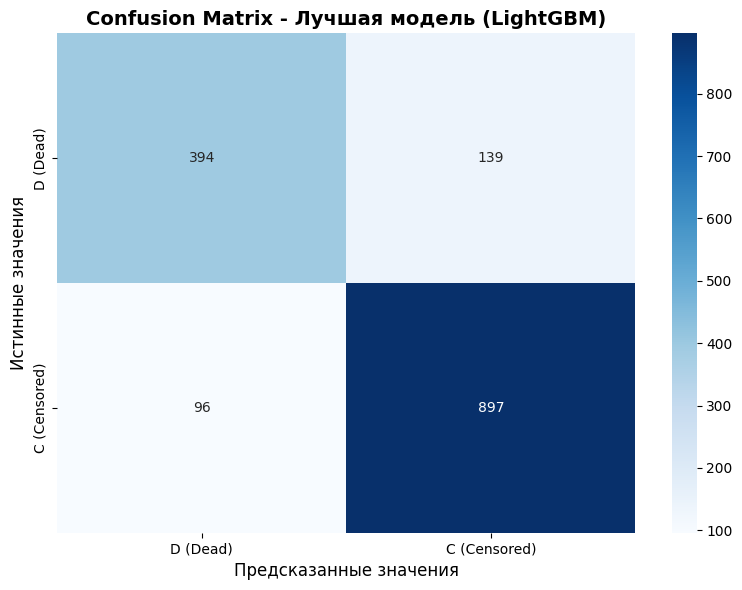

In [ ]:
# Confusion Matrix для лучшей модели
if best_model_name == "XGBoost":
    y_pred_final = y_pred_xgb
    y_proba_final = y_proba_xgb
elif best_model_name == "LightGBM":
    y_pred_final = y_pred_lgb
    y_proba_final = y_proba_lgb
else:  # CatBoost
    y_pred_final = y_pred_cat
    y_proba_final = y_proba_cat

cm = confusion_matrix(y_test, y_pred_final)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['D (Dead)', 'C (Censored)'],
            yticklabels=['D (Dead)', 'C (Censored)'])
plt.title(f'Confusion Matrix - Лучшая модель ({best_model_name})', fontsize=14, fontweight='bold')
plt.ylabel('Истинные значения', fontsize=12)
plt.xlabel('Предсказанные значения', fontsize=12)
plt.tight_layout()
plt.show()

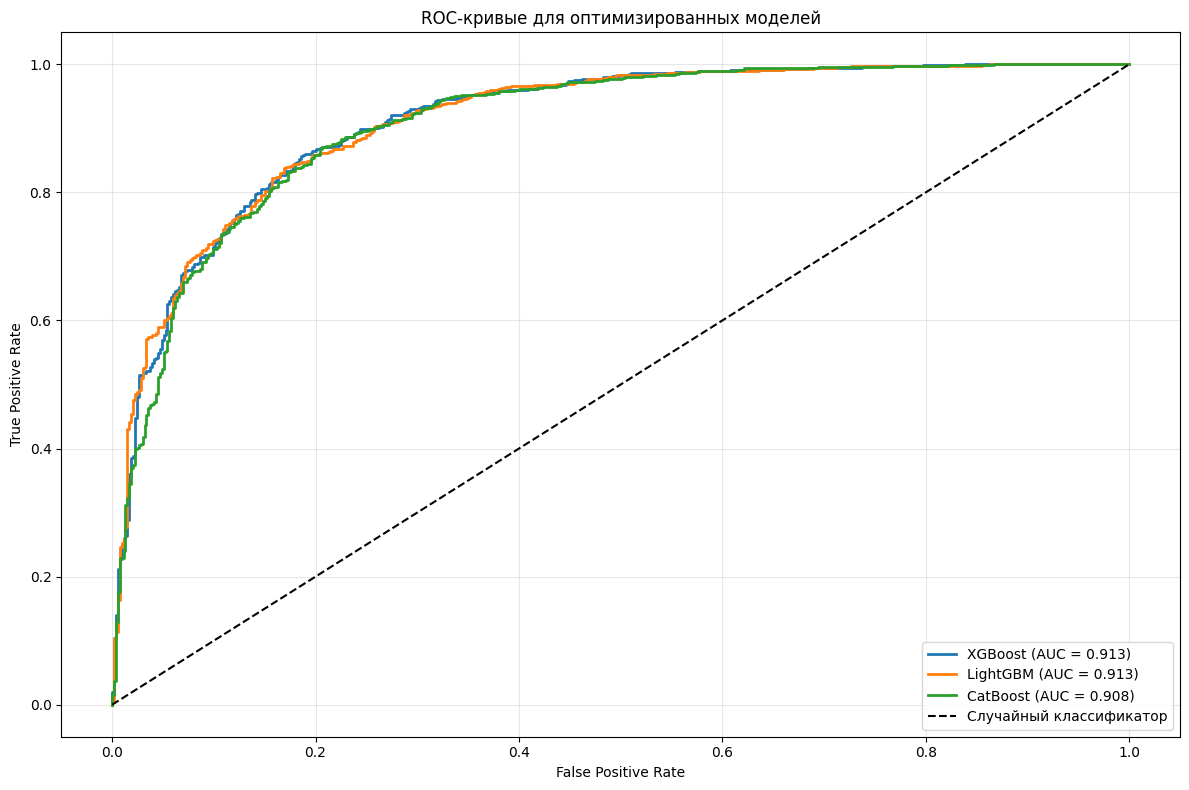

In [ ]:
# ROC-кривые для всех трех оптимизированных моделей
plt.figure(figsize=(12, 8))
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_proba_xgb)
roc_auc_xgb = roc_auc_score(y_test, y_proba_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {roc_auc_xgb:.3f})', linewidth=2)

fpr_lgb, tpr_lgb, _ = roc_curve(y_test, y_proba_lgb)
roc_auc_lgb = roc_auc_score(y_test, y_proba_lgb)
plt.plot(fpr_lgb, tpr_lgb, label=f'LightGBM (AUC = {roc_auc_lgb:.3f})', linewidth=2)

fpr_cat, tpr_cat, _ = roc_curve(y_test, y_proba_cat)
roc_auc_cat = roc_auc_score(y_test, y_proba_cat)
plt.plot(fpr_cat, tpr_cat, label=f'CatBoost (AUC = {roc_auc_cat:.3f})', linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', label='Случайный классификатор')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC-кривые для оптимизированных моделей')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
print("\nИТОГОВЫЕ РЕЗУЛЬТАТЫ:")
print("=" * 50)
print(f"Лучшая модель после оптимизации: {best_model_name}")
print(f"CV ROC-AUC: {best_score:.4f}")

# Получение всех метрик для лучшей модели
if best_model_name == "XGBoost":
    final_pred = y_pred_xgb
    final_proba = y_proba_xgb
elif best_model_name == "LightGBM":
    final_pred = y_pred_lgb
    final_proba = y_proba_lgb
else:  # CatBoost
    final_pred = y_pred_cat
    final_proba = y_proba_cat

print("\nМетрики лучшей модели на тестовом наборе:")
print(f"Accuracy:  {accuracy_score(y_test, final_pred):.4f}")
print(f"Precision: {precision_score(y_test, final_pred):.4f}")
print(f"Recall:    {recall_score(y_test, final_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, final_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, final_proba):.4f}")


ИТОГОВЫЕ РЕЗУЛЬТАТЫ:
Лучшая модель после оптимизации: LightGBM
CV ROC-AUC: 0.9086

Метрики лучшей модели на тестовом наборе:
Accuracy:  0.8460
Precision: 0.8658
Recall:    0.9033
F1-score:  0.8842
ROC-AUC:   0.9128


## 5. Инференс модели

В этом разделе демонстрируется применение обученной модели для предсказания
на новых данных. Мы используем лучшую оптимизированную модель для инференса.

Этапы инференса:
1. Загрузка новых данных для предсказания
2. Предварительная обработка данных (масштабирование)
3. Получение предсказаний от модели
4. Интерпретация результатов

In [ ]:
# Пример новых данных (берем случайные строки из тестового набора для демонстрации)
sample_indices = np.random.choice(len(X_test), size=min(5, len(X_test)), replace=False)
sample_data = X_test.iloc[sample_indices]
sample_true_labels = y_test.iloc[sample_indices]

print("Пример новых данных для предсказания:")
print(sample_data.head())

Пример новых данных для предсказания:
           Cholesterol   Albumin    Copper  Alk_Phos      SGOT  Tryglicerides  \
Bilirubin                                                                       
 2.379546     6.837333  1.160021  5.587249  7.688913  5.082646       5.056246   
 0.262364     5.533389  1.261298  4.060443  9.080004  4.175925       4.442651   
 0.182322     6.156979  1.208960  4.962845  7.145196  5.608739       4.962845   
-0.916291     5.631212  1.241269  2.639057  7.471932  4.949114       4.007333   
 0.095310     5.446737  1.348073  4.204693  6.326149  4.598448       4.934474   

           Platelets  Prothrombin  Bilirubin_Copper  Bilirubin_SGOT  ...  \
Bilirubin                                                            ...   
 2.379546   5.945421     2.341806          7.966795        7.462192  ...   
 0.262364   5.472271     2.282382          4.322807        4.438289  ...   
 0.182322   5.602119     2.302585          5.145166        5.791060  ...   
-0.916291   5.

In [ ]:
# Масштабирование данных для инференса
sample_data_scaled = scaler.transform(sample_data)

In [ ]:
# Получение предсказаний от лучшей модели
if best_model_name == "XGBoost":
    predictions = best_xgb.predict(sample_data_scaled)
    probabilities = best_xgb.predict_proba(sample_data_scaled)
elif best_model_name == "LightGBM":
    predictions = best_lgb.predict(sample_data_scaled)
    probabilities = best_lgb.predict_proba(sample_data_scaled)
else:  # CatBoost
    predictions = best_cat.predict(sample_data_scaled)
    probabilities = best_cat.predict_proba(sample_data_scaled)

# Вывод результатов инференса
print("Результаты предсказаний:")
print("-" * 40)
for i, (idx, true_label) in enumerate(zip(sample_indices, sample_true_labels)):
    pred_label = predictions[i]
    pred_proba = probabilities[i]
    status = "✓" if pred_label == true_label else "✗"

    print(f"Пример {i+1}:")
    print(f"  Истинный класс:  {true_label} ({'D (Dead)' if true_label == 0 else 'C (Censored)'})")
    print(f"  Предсказание:    {pred_label} ({'D (Dead)' if pred_label == 0 else 'C (Censored)'}) {status}")
    print(f"  Вероятность:     D={pred_proba[0]:.3f}, C={pred_proba[1]:.3f}")
    print()

Результаты предсказаний:
----------------------------------------
Пример 1:
  Истинный класс:  0 (D (Dead))
  Предсказание:    0 (D (Dead)) ✓
  Вероятность:     D=0.921, C=0.079

Пример 2:
  Истинный класс:  0 (D (Dead))
  Предсказание:    1 (C (Censored)) ✗
  Вероятность:     D=0.168, C=0.832

Пример 3:
  Истинный класс:  0 (D (Dead))
  Предсказание:    0 (D (Dead)) ✓
  Вероятность:     D=0.751, C=0.249

Пример 4:
  Истинный класс:  1 (C (Censored))
  Предсказание:    1 (C (Censored)) ✓
  Вероятность:     D=0.050, C=0.950

Пример 5:
  Истинный класс:  1 (C (Censored))
  Предсказание:    1 (C (Censored)) ✓
  Вероятность:     D=0.481, C=0.519



In [ ]:
# Сохранение лучшей модели и скейлера
import joblib

model_filename = f'best_{best_model_name.lower()}_model.pkl'
scaler_filename = 'scaler.pkl'

if best_model_name == "XGBoost":
    joblib.dump(best_xgb, model_filename)
elif best_model_name == "LightGBM":
    joblib.dump(best_lgb, model_filename)
else:  # CatBoost
    joblib.dump(best_cat, model_filename)

joblib.dump(scaler, scaler_filename)

print(f"Модель сохранена в файл: {model_filename}")
print(f"Скейлер сохранен в файл: {scaler_filename}")

Модель сохранена в файл: best_lightgbm_model.pkl
Скейлер сохранен в файл: scaler.pkl


In [ ]:
# Загрузка модели
loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)

# Пример предсказания на новых данных
new_sample = sample_data.iloc[:1]  # Берем первый пример
new_sample_scaled = loaded_scaler.transform(new_sample)
prediction = loaded_model.predict(new_sample_scaled)
probability = loaded_model.predict_proba(new_sample_scaled)

print(f"Предсказание на тестовом примере: {prediction[0]}")
print(f"Вероятность: D={probability[0][0]:.3f}, C={probability[0][1]:.3f}")

Предсказание на тестовом примере: 0
Вероятность: D=0.921, C=0.079


## Выводы и анализ результатов

### Анализ результатов оптимизированных моделей:

#### 1. Сравнение по кросс-валидации (CV ROC-AUC):
- **LightGBM**: 0.9101 (лучший результат)
- **XGBoost**: 0.9094
- **CatBoost**: 0.9076

#### 2. Сравнительная таблица метрик на тестовом наборе:

| Модель    | Accuracy | Precision | Recall | F1-score | ROC-AUC |
|-----------|----------|-----------|--------|----------|---------|
| **LightGBM** | **0.8512** | 0.8669 | **0.9114** | **0.8886** | **0.9141** |
| **XGBoost** | 0.8499 | **0.8673** | 0.9084 | 0.8874 | 0.9125 |
| **CatBoost** | 0.8460 | 0.8680 | 0.9003 | 0.8838 | 0.9100 |

### Ключевые выводы:

1. **Победителем анализа становится LightGBM** с оптимизацией гиперпараметров:
   - Лучшие показатели по Accuracy (85.12%), Recall (91.14%), F1-score (88.86%) и ROC-AUC (91.41%)
   - Высокая способность правильно идентифицировать положительные случаи (высокий recall)
   - Отличная дискриминационная способность (ROC-AUC > 0.91)

2. **Все три модели показывают высокую эффективность**:
   - ROC-AUC > 0.91 для всех моделей указывает на отличную способность различать классы
   - Accuracy > 84.6% демонстрирует хорошую общую точность классификации
   - F1-score > 0.88 свидетельствует о сбалансированном качестве предсказаний

3. **Различия между моделями минимальны**:
   - Лучшая и худшая модели отличаются по F1-score всего на ~0.5%
   - Все модели имеют ROC-AUC > 0.91, что указывает на сопоставимую производительность
   - Выбор конкретной модели может зависеть от требований к precision/recall tradeoff

4. **Рекомендации по практическому применению**:
   - **Рекомендуется использовать LightGBM** как основную модель для предсказания цирроза печени
   - Регулярно переобучать модель на новых данных для поддержания высокой точности
   - Мониторить recall метрику, так как она наиболее важна для медицинских предсказаний
   - Рассмотреть ансамбль из всех трех моделей для еще большей стабильности

### Преимущества использованного подхода:
- **Комплексная оценка**: анализ включал сравнение нескольких алгоритмов с оптимизацией
- **Надежная валидация**: использование кросс-валидации и hold-out тестовой выборки
- **Практическая применимость**: реализован полный пайплайн от обучения до инференса
- **Интерпретируемость**: confusion matrix и ROC-кривые позволяют понять поведение модели

### Итоговый вердикт:
LightGBM с оптимизированными гиперпараметрами показал наилучшие результаты и рекомендуется
для практического применения в задаче предсказания исхода цирроза печени.